# 🔍 Deteksi Penipuan Lowongan Kerja Freelance
### Berbasis Logistic Regression + TF-IDF + Red Flags Detection

**Dataset:** fake_job_postings.csv (Kaggle - Shivam Bansal)

**Alur kerja:**
1. Import Library
2. Load & Eksplorasi Dataset
3. Preprocessing Data
4. Ekstraksi Fitur (TF-IDF + Red Flags)
5. Training Model (Logistic Regression)
6. Evaluasi Model
7. Simpan Model
8. Prediksi Manual

---
## 1. Import Library

In [111]:
# Install jika perlu
# !pip install nltk scikit-learn pandas numpy imbalanced-learn

import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from scipy.sparse import hstack, csr_matrix
import seaborn as sns
import joblib


# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix


# 🔥 tambahan penting
from imblearn.over_sampling import SMOTE

# optional
from sklearn.metrics import precision_recall_curve

# Download NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

---
## 2. Load & Eksplorasi Dataset

In [112]:
# Load dataset

df = pd.read_csv('fake_job_postings.csv')

print(f'Shape dataset: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Shape dataset: (17880, 18)
Kolom: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [113]:
# Informasi dasar dataset
print('=== Info Dataset ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function    

=== Distribusi Label ===
fraudulent
0    17014
1      866
Name: count, dtype: int64

Persentase penipuan: 4.84%


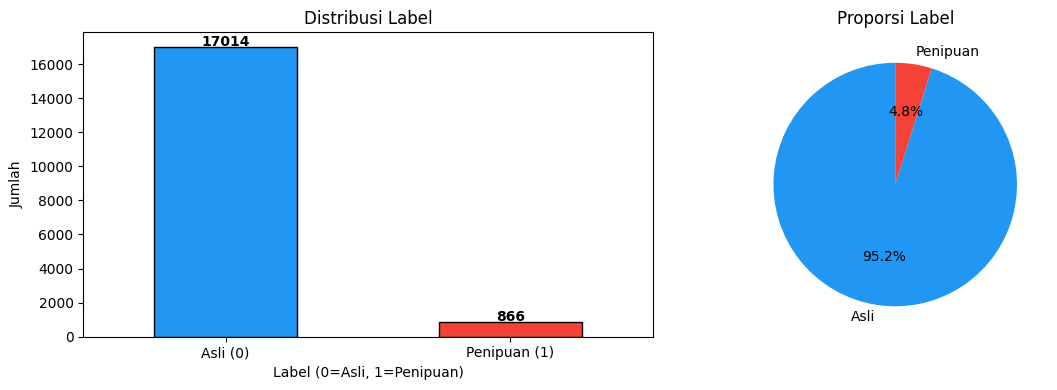

✅ Grafik distribusi label tersimpan.


In [114]:
print('=== Distribusi Label ===')
counts = df['fraudulent'].value_counts().sort_index()
print(counts)
print(f"\nPersentase penipuan: {df['fraudulent'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts.plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#F44336'],
    edgecolor='black'
)

axes[0].set_title('Distribusi Label')
axes[0].set_xlabel('Label (0=Asli, 1=Penipuan)')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Asli (0)', 'Penipuan (1)'], rotation=0)

# Tambah angka di atas bar
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
counts.plot(
    kind='pie', ax=axes[1],
    labels=['Asli', 'Penipuan'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#F44336'],
    startangle=90
)

axes[1].set_title('Proporsi Label')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Grafik distribusi label tersimpan.')

---
## 3. Preprocessing Data

In [115]:
# ============================================================
# Daftar Red Flags dan Link Mencurigakan
# ============================================================

RED_FLAGS = [
    # Bahasa Indonesia
    'tanpa modal', 'tanpa pengalaman', 'tanpa syarat',
    'gaji besar', 'gaji tinggi', 'penghasilan besar',
    'komisi harian', 'bonus harian', 'langsung cair',
    'tugas mudah', 'kerja mudah', 'pekerjaan mudah',
    'like rating', 'like dan rating', 'tugas like',
    'deposit', 'top up', 'bayar dulu', 'transfer dulu',
    'verifikasi akun', 'biaya pendaftaran',
    'segera daftar', 'daftar sekarang', 'buruan daftar',
    'slot terbatas', 'kuota terbatas',
    'admin online', 'data entry mudah',
    # Bahasa Inggris
    'no experience', 'no skills required',
    'work from home easy', 'easy money',
    'earn from home', 'make money fast',
    'unlimited income', 'passive income',
    'registration fee', 'payment required',
    'wire transfer', 'western union',
    'act now', 'limited slots', 'urgent hiring',
]

SUSPICIOUS_LINKS = [
    't.me', 'wa.me', 'bit.ly', 'tinyurl.com',
    'shorturl.at', 'cutt.ly', 'rebrand.ly',
    'linktr.ee', 'taplink.cc'
]

print(f'✅ Red flags terdaftar: {len(RED_FLAGS)}')
print(f'✅ Suspicious links terdaftar: {len(SUSPICIOUS_LINKS)}')

✅ Red flags terdaftar: 43
✅ Suspicious links terdaftar: 9


In [116]:
# ============================================================
# Fungsi Preprocessing
# ============================================================

# Stopwords gabungan Indonesia + Inggris
stop_words_en = set(stopwords.words('english'))
stop_words_id = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu',
    'dengan', 'untuk', 'pada', 'adalah', 'akan', 'tidak',
    'dalam', 'juga', 'sudah', 'saya', 'kami', 'kita',
    'bisa', 'ada', 'atau', 'jika', 'serta', 'oleh',
    'lebih', 'dapat', 'saat', 'telah', 'agar', 'hal',
    'lain', 'setelah', 'namun', 'bahwa', 'anda', 'kami'
}
all_stopwords = stop_words_en | stop_words_id


def count_red_flags(text):
    """Menghitung jumlah red flags dalam teks."""
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for flag in RED_FLAGS if flag in text_lower)


def detect_suspicious_links(text):
    """Mendeteksi link mencurigakan dalam teks."""
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    return [link for link in SUSPICIOUS_LINKS if link in text_lower]


def preprocess_text(text):
    """Membersihkan dan memproses teks."""
    if not isinstance(text, str):
        return ''
    # Konversi ke huruf kecil
    text = text.lower()
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Hapus link khusus
    for link in SUSPICIOUS_LINKS:
        text = text.replace(link, ' ')
    # Hapus mention dan hashtag
    text = re.sub(r'[@#]\w+', ' ', text)
    # Hapus angka
    text = re.sub(r'\d+', ' ', text)
    # Hapus karakter khusus dan tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)
    # Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenisasi dan hapus stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    return ' '.join(tokens)


print('✅ Fungsi preprocessing berhasil didefinisikan.')

✅ Fungsi preprocessing berhasil didefinisikan.


In [117]:
# ============================================================
# Terapkan Preprocessing ke Dataset
# ============================================================

# Gabungkan kolom teks yang relevan
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df['combined_text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

# Hitung red flags SEBELUM preprocessing (pada teks asli)
df['red_flag_count'] = df['combined_text'].apply(count_red_flags)
df['suspicious_links'] = df['combined_text'].apply(detect_suspicious_links)
df['has_suspicious_link'] = df['suspicious_links'].apply(lambda x: 1 if x else 0)

# Preprocessing teks
print('⏳ Sedang melakukan preprocessing... (mungkin memerlukan beberapa menit)')
df['clean_text'] = df['combined_text'].apply(preprocess_text)

print(f'✅ Preprocessing selesai!')
print(f'Contoh teks asli:\n{df["combined_text"].iloc[0][:200]}...')
print(f'\nContoh teks bersih:\n{df["clean_text"].iloc[0][:200]}...')

⏳ Sedang melakukan preprocessing... (mungkin memerlukan beberapa menit)
✅ Preprocessing selesai!
Contoh teks asli:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have...

Contoh teks bersih:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cooks give everything need one place top editorial business engineering team focused using techno...


=== Rata-rata Red Flag per Kelas ===
              count      mean       std  min  25%  50%  75%  max
fraudulent                                                      
0           17014.0  0.019455  0.146384  0.0  0.0  0.0  0.0  2.0
1             866.0  0.080831  0.276940  0.0  0.0  0.0  0.0  2.0


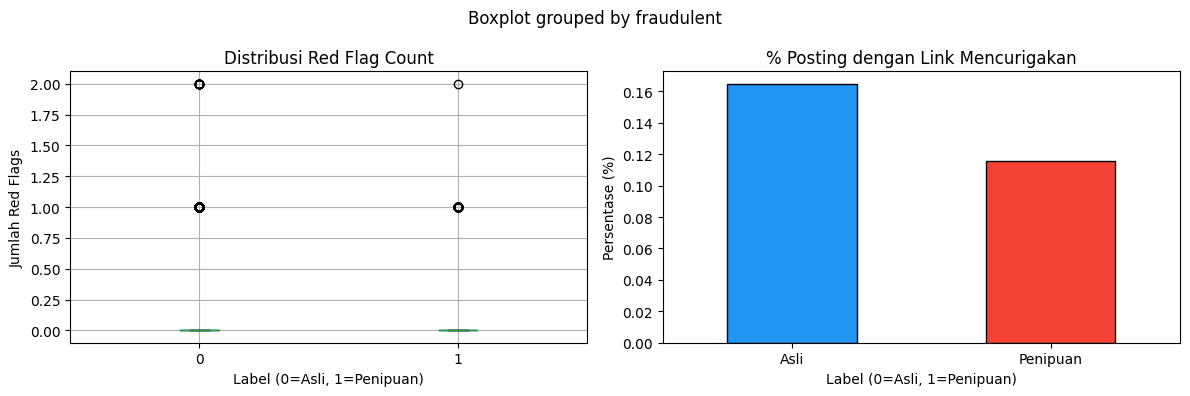

In [118]:
# Analisis Red Flags per Kelas
print('=== Rata-rata Red Flag per Kelas ===')
print(df.groupby('fraudulent')['red_flag_count'].describe())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot red flag count
df.boxplot(column='red_flag_count', by='fraudulent', ax=axes[0])
axes[0].set_title('Distribusi Red Flag Count')
axes[0].set_xlabel('Label (0=Asli, 1=Penipuan)')
axes[0].set_ylabel('Jumlah Red Flags')

# Proporsi yang memiliki link mencurigakan
link_stats = df.groupby('fraudulent')['has_suspicious_link'].mean() * 100
link_stats.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='black')
axes[1].set_title('% Posting dengan Link Mencurigakan')
axes[1].set_xlabel('Label (0=Asli, 1=Penipuan)')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xticklabels(['Asli', 'Penipuan'], rotation=0)

plt.tight_layout()
plt.savefig('analisis_red_flags.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Ekstraksi Fitur (TF-IDF + Red Flags)

In [119]:
# ============================================================
# Split Data Train & Test
# ============================================================

X_text = df['clean_text']
X_extra = df[['red_flag_count', 'has_suspicious_link']]
y = df['fraudulent']

X_text_train, X_text_test, X_extra_train, X_extra_test, y_train, y_test = train_test_split(
    X_text, X_extra, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Data train: {len(X_text_train)} sampel')
print(f'Data test : {len(X_text_test)} sampel')
print(f'Distribusi y_train: {dict(y_train.value_counts())}')
print(f'Distribusi y_test : {dict(y_test.value_counts())}')

Data train: 14304 sampel
Data test : 3576 sampel
Distribusi y_train: {0: np.int64(13611), 1: np.int64(693)}
Distribusi y_test : {0: np.int64(3403), 1: np.int64(173)}


In [120]:
# ============================================================
# TF-IDF Vectorizer
# ============================================================

from sklearn.preprocessing import StandardScaler

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=3,
    max_df=0.9
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

# 🔥 Scaling fitur tambahan (WAJIB)
scaler = StandardScaler(with_mean=False)
X_extra_train_scaled = scaler.fit_transform(X_extra_train)
X_extra_test_scaled  = scaler.transform(X_extra_test)

# Gabungkan fitur
X_train_combined = hstack([
    X_tfidf_train,
    csr_matrix(X_extra_train_scaled)
])

X_test_combined = hstack([
    X_tfidf_test,
    csr_matrix(X_extra_test_scaled)
])

print(f'✅ Shape fitur train: {X_train_combined.shape}')
print(f'✅ Shape fitur test : {X_test_combined.shape}')

✅ Shape fitur train: (14304, 8002)
✅ Shape fitur test : (3576, 8002)


---
## 5. Training Model (Logistic Regression)

In [ ]:
# ============================================================
# Training Logistic Regression / Random forest
# ============================================================

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_combined, y_train)

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_res, y_res)

print('✅ Model berhasil dilatih!')
print(f'Kelas: {model.classes_}')
print(f'Jumlah fitur: {model.n_features_in_}')

✅ Model berhasil dilatih!
Kelas: [0 1]
Jumlah fitur: 8002


---
## 6. Evaluasi Model

In [122]:
# ============================================================
# Evaluasi Performa Model
# ============================================================

y_proba = model.predict_proba(X_test_combined)[:,1]

# 🔥 Cari threshold terbaik
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_temp = (y_proba > t).astype(int)
    f1_temp = f1_score(y_test, y_pred_temp)
    
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = t

print(f'Best Threshold: {best_threshold:.2f}')
print(f'Best F1 Score : {best_f1:.4f}')

# Pakai threshold terbaik
y_pred = (y_proba > best_threshold).astype(int)

# Hitung metric
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print('           HASIL EVALUASI MODEL')
print('=' * 45)
print(f'  Akurasi  : {acc*100:.2f}%')
print(f'  Presisi  : {prec*100:.2f}%')
print(f'  Recall   : {rec*100:.2f}%')
print(f'  F1-Score : {f1*100:.2f}%')
print('=' * 45)

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Asli', 'Penipuan']))

Best Threshold: 0.60
Best F1 Score : 0.8622
           HASIL EVALUASI MODEL
  Akurasi  : 98.69%
  Presisi  : 87.50%
  Recall   : 84.97%
  F1-Score : 86.22%

=== Classification Report ===
              precision    recall  f1-score   support

        Asli       0.99      0.99      0.99      3403
    Penipuan       0.88      0.85      0.86       173

    accuracy                           0.99      3576
   macro avg       0.93      0.92      0.93      3576
weighted avg       0.99      0.99      0.99      3576



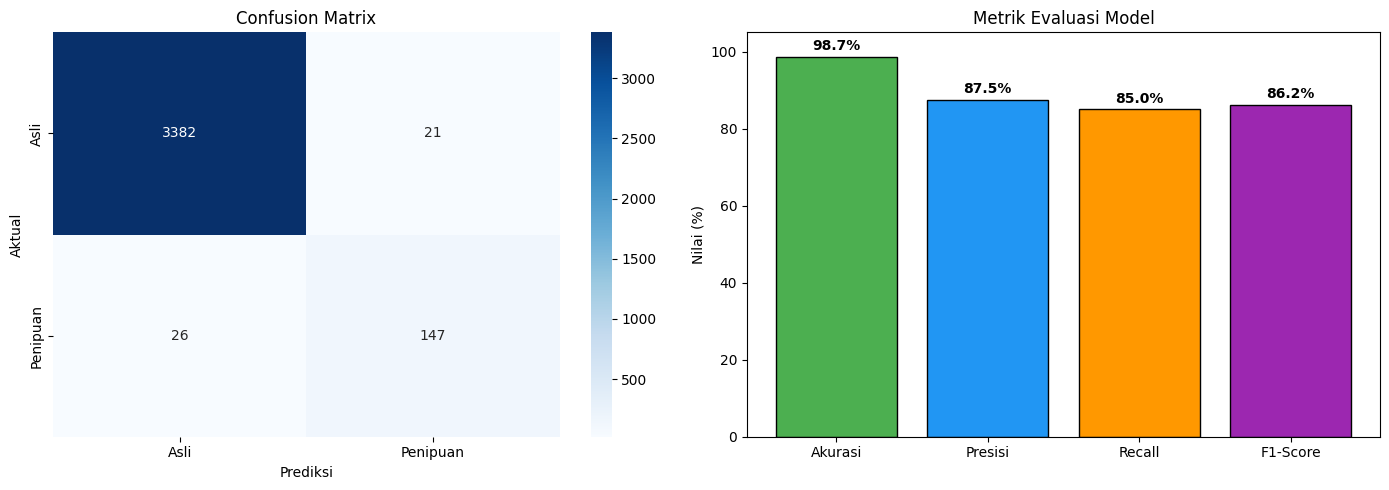

✅ Grafik evaluasi tersimpan.


In [123]:
# ============================================================
# Visualisasi Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Asli', 'Penipuan'],
    yticklabels=['Asli', 'Penipuan'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Bar chart metrik
metrics = {'Akurasi': acc, 'Presisi': prec, 'Recall': rec, 'F1-Score': f1}
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = axes[1].bar(metrics.keys(), [v*100 for v in metrics.values()], color=colors, edgecolor='black')
axes[1].set_title('Metrik Evaluasi Model')
axes[1].set_ylabel('Nilai (%)')
axes[1].set_ylim(0, 105)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val*100:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik evaluasi tersimpan.')

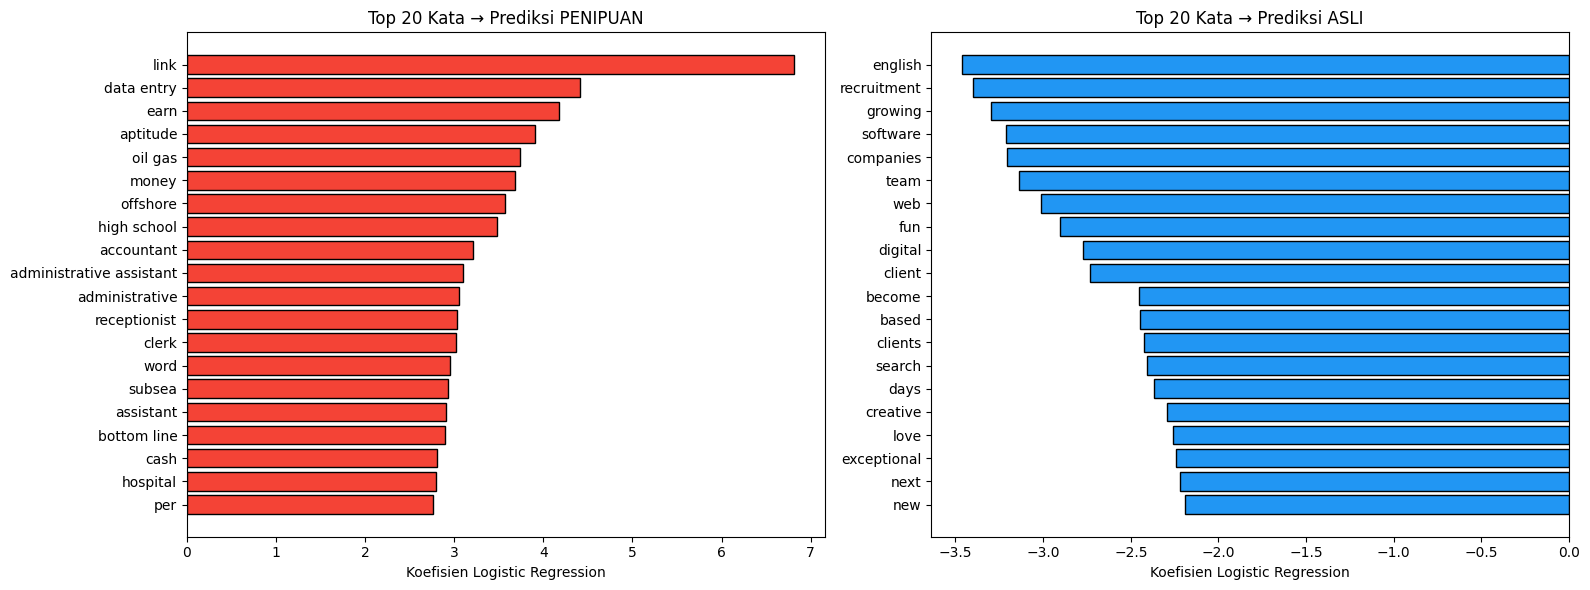

In [125]:
# ============================================================
# Top 20 Kata Paling Berpengaruh per Kelas
# ============================================================

# Ambil nama fitur dari TF-IDF + fitur tambahan
feature_names = tfidf.get_feature_names_out().tolist() + ['red_flag_count', 'has_suspicious_link']

# Ambil koefisien model (kelas 1 biasanya "Penipuan")
coef = model.coef_[0]

# Top fitur untuk kelas penipuan (nilai koefisien besar positif)
top_n = 20
fraud_idx = np.argsort(coef)[-top_n:][::-1]

# Top fitur untuk kelas asli (nilai koefisien besar negatif)
legit_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kata top untuk PENIPUAN
fraud_words = [feature_names[i] for i in fraud_idx]
fraud_scores = [coef[i] for i in fraud_idx]
axes[0].barh(fraud_words[::-1], fraud_scores[::-1], color='#F44336', edgecolor='black')
axes[0].set_title('Top 20 Kata → Prediksi PENIPUAN')
axes[0].set_xlabel('Koefisien Logistic Regression')

# Kata top untuk ASLI
legit_words = [feature_names[i] for i in legit_idx]
legit_scores = [coef[i] for i in legit_idx]
axes[1].barh(legit_words[::-1], legit_scores[::-1], color='#2196F3', edgecolor='black')
axes[1].set_title('Top 20 Kata → Prediksi ASLI')
axes[1].set_xlabel('Koefisien Logistic Regression')

plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Simpan Model

In [126]:
# ============================================================
# Simpan Model dan TF-IDF Vectorizer
# ============================================================

# Simpan semua yang dibutuhkan
joblib.dump(model, 'model_logreg.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('✅ Model tersimpan: model_logreg.pkl')
print('✅ TF-IDF tersimpan: tfidf_vectorizer.pkl')
print('✅ Scaler tersimpan: scaler.pkl')

print('\nUntuk memuat kembali:')
print("model  = joblib.load('model_logreg.pkl')")
print("tfidf  = joblib.load('tfidf_vectorizer.pkl')")
print("scaler = joblib.load('scaler.pkl')")

✅ Model tersimpan: model_logreg.pkl
✅ TF-IDF tersimpan: tfidf_vectorizer.pkl
✅ Scaler tersimpan: scaler.pkl

Untuk memuat kembali:
model  = joblib.load('model_logreg.pkl')
tfidf  = joblib.load('tfidf_vectorizer.pkl')
scaler = joblib.load('scaler.pkl')


---
## 8. Prediksi Manual

In [127]:
# ============================================================
# Fungsi Prediksi untuk Teks Baru
# ============================================================

def prediksi_lowongan(teks_lowongan: str) -> dict:
    """
    Memprediksi apakah suatu lowongan kerja berpotensi penipuan.

    Parameters:
        teks_lowongan (str): Deskripsi teks lowongan kerja.

    Returns:
        dict: Hasil prediksi beserta detail analisis.
    """
    # Hitung red flags dan link mencurigakan dari teks asli
    jumlah_red_flags = count_red_flags(teks_lowongan)
    link_curiga = detect_suspicious_links(teks_lowongan)
    has_link = 1 if link_curiga else 0

    # Rincian red flags yang ditemukan
    teks_lower = teks_lowongan.lower()
    flags_ditemukan = [flag for flag in RED_FLAGS if flag in teks_lower]

    # Preprocessing
    teks_bersih = preprocess_text(teks_lowongan)

    # Ekstraksi fitur
    X_tfidf = tfidf.transform([teks_bersih])
    X_extra = csr_matrix([[jumlah_red_flags, has_link]])
    X_combined = hstack([X_tfidf, X_extra])

    # Prediksi
    label = model.predict(X_combined)[0]
    proba = model.predict_proba(X_combined)[0]

    hasil = {
        'label': 'PENIPUAN ⚠️' if label == 1 else 'ASLI ✅',
        'kode_label': int(label),
        'probabilitas_penipuan': f'{proba[1]*100:.1f}%',
        'probabilitas_asli': f'{proba[0]*100:.1f}%',
        'jumlah_red_flags': jumlah_red_flags,
        'red_flags_ditemukan': flags_ditemukan if flags_ditemukan else ['(tidak ada)'],
        'link_mencurigakan': link_curiga if link_curiga else ['(tidak ada)'],
    }
    return hasil


def tampilkan_hasil(hasil: dict):
    """Menampilkan hasil prediksi dengan format yang rapi."""
    print('=' * 50)
    print('       HASIL DETEKSI LOWONGAN KERJA')
    print('=' * 50)
    print(f'  Status       : {hasil["label"]}')
    print(f'  Prob. Penipuan: {hasil["probabilitas_penipuan"]}')
    print(f'  Prob. Asli    : {hasil["probabilitas_asli"]}')
    print(f'  Red Flags     : {hasil["jumlah_red_flags"]} ditemukan')
    print(f'  Detail Flags  : {", ".join(hasil["red_flags_ditemukan"])}')
    print(f'  Link Curiga   : {", ".join(hasil["link_mencurigakan"])}')
    print('=' * 50)


print('✅ Fungsi prediksi siap digunakan.')

✅ Fungsi prediksi siap digunakan.


---
## 📚 Referensi

- Bansal, S. (2020). *Real or Fake? Fake Job Posting Prediction* [Dataset]. Kaggle. https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press.
- Salton, G., & Buckley, C. (1988). Term-Weighting Approaches in Automatic Text Retrieval. *Information Processing & Management*, 24(5), 513–523.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media.

---
*Penelitian: Deteksi Penipuan Lowongan Kerja Freelance | 3IA12*